=== TSP — Simulated Annealing ===
Distância total ≈ 9123 km
Rota (SA): ['São Paulo', 'Santos', 'Campinas', 'Curitiba', 'Florianópolis', 'Porto Alegre', 'Rio de Janeiro', 'Belo Horizonte', 'Vitória', 'Salvador', 'Aracaju', 'Recife', 'João Pessoa', 'Natal', 'Fortaleza', 'Teresina', 'São Luís', 'Belém', 'Brasília', 'Goiânia']


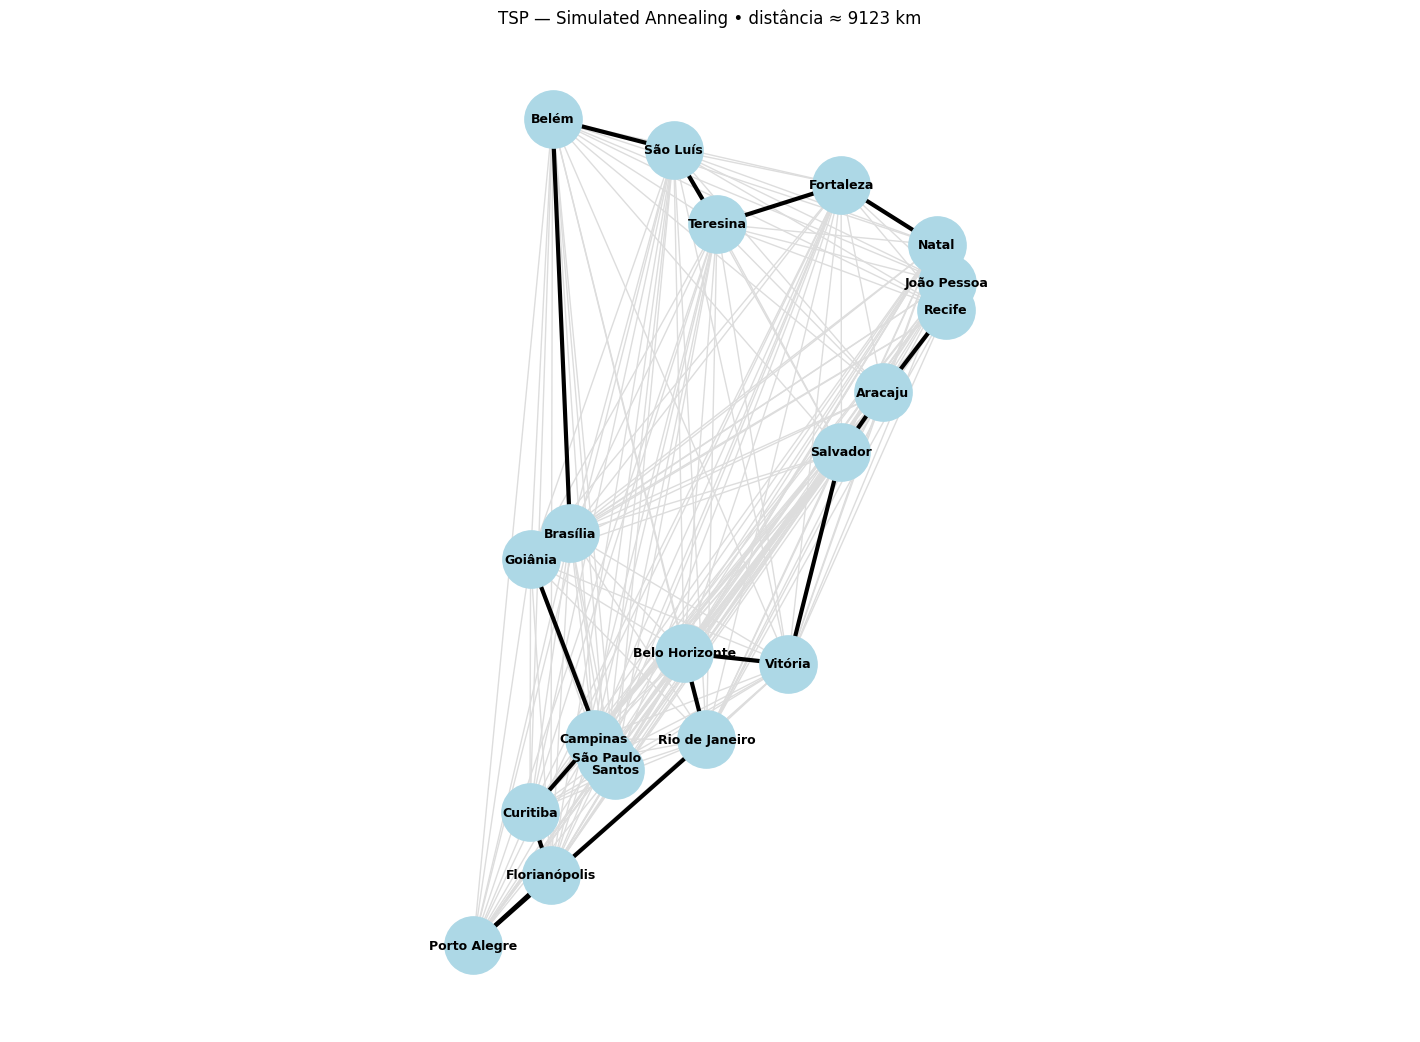

In [22]:
import math, itertools as it, random
import networkx as nx
import matplotlib.pyplot as plt
from functools import partial
from networkx.algorithms.approximation import traveling_salesman as tsp

random.seed(42)

# -----------------------------
# 1) 20 cidades (lat, lon)
# -----------------------------
coords = {
    "São Paulo": (-23.55, -46.63), "Rio de Janeiro": (-22.91, -43.17),
    "Belo Horizonte": (-19.92, -43.94), "Curitiba": (-25.43, -49.27),
    "Campinas": (-22.90, -47.06), "Santos": (-23.96, -46.33),
    "Vitória": (-20.31, -40.34), "Porto Alegre": (-30.03, -51.23),
    "Florianópolis": (-27.59, -48.55), "Brasília": (-15.79, -47.88),
    "Goiânia": (-16.68, -49.25), "Salvador": (-12.97, -38.50),
    "Aracaju": (-10.91, -37.07), "Recife": (-8.05, -34.88),
    "João Pessoa": (-7.12, -34.86), "Natal": (-5.81, -35.21),
    "Fortaleza": (-3.73, -38.51), "Teresina": (-5.09, -42.80),
    "São Luís": (-2.53, -44.30), "Belém": (-1.45, -48.49),
}

# -----------------------------
# 2) Haversine (km)
# -----------------------------
R = 6371.0
def haversine(p1, p2):
    lat1, lon1 = map(math.radians, p1)
    lat2, lon2 = map(math.radians, p2)
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = (math.sin(dlat/2)**2
         + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2)
    return 2 * R * math.asin(math.sqrt(a))

# -----------------------------
# 3) Grafo completo (peso = km)
# -----------------------------
G = nx.Graph()
G.add_nodes_from(coords.keys())
for u, v in it.combinations(G.nodes, 2):
    G.add_edge(u, v, weight=round(haversine(coords[u], coords[v]), 1))

# -----------------------------
# 4) TSP com Simulated Annealing
#    -> precisamos fornecer init_cycle
# -----------------------------
# Rota inicial simples (ex.: ordem dos nós) ou melhor: usar greedy como semente
init_cycle = tsp.greedy_tsp(G, weight="weight")  # boa semente para o SA
# init_cycle = list(G.nodes())  # alternativa mais simples

sa_method = partial(
    tsp.simulated_annealing_tsp,
    init_cycle=init_cycle,
    weight="weight",
    # hiperparâmetros opcionais (ajuste se quiser explorar mais):
    temp=10000,            # temperatura inicial
    move="1-1",            # vizinhança (swap 2-opt simples)
    max_iterations=20000,  # iterações externas
)

tour_sa = tsp.traveling_salesman_problem(G, weight="weight", cycle=True, method=sa_method)

# normaliza (remove repetição final, se houver)
if len(tour_sa) > 1 and tour_sa[0] == tour_sa[-1]:
    tour_sa = tour_sa[:-1]

def comprimento(G, tour):
    return sum(G[u][v]["weight"] for u, v in zip(tour, tour[1:] + [tour[0]]))

len_sa = comprimento(G, tour_sa)
print("=== TSP — Simulated Annealing ===")
print(f"Distância total ≈ {len_sa:.0f} km")
print("Rota (SA):", tour_sa)

# -----------------------------
# 5) Plot (lon, lat)
# -----------------------------
pos = {c: (coords[c][1], coords[c][0]) for c in G.nodes()}
plt.figure(figsize=(14, 10), constrained_layout=True)
nx.draw(G, pos, with_labels=True, node_size=1700, node_color="lightblue",
        font_size=9, font_weight="bold", edge_color="#dddddd")

tour_edges = [(tour_sa[i], tour_sa[(i+1) % len(tour_sa)]) for i in range(len(tour_sa))]
nx.draw_networkx_edges(G, pos, edgelist=tour_edges, width=3)

plt.title(f"TSP — Simulated Annealing • distância ≈ {len_sa:.0f} km")
plt.axis("equal")
plt.show()


# Melhor Solução do TSP (20 cidades do Brasil)

✅ **Distância total ótima:** **≈ 8.883 km**

Essa é a rota de **menor distância possível**, visitando todas as cidades **exatamente uma vez** e retornando ao ponto de partida.


### 🚍 Rota ótima:

**São Paulo → Curitiba → Porto Alegre → Florianópolis → Santos → Rio de Janeiro → Belo Horizonte → Vitória → Salvador → Aracaju → Recife → João Pessoa → Natal → Fortaleza → Teresina → São Luís → Belém → Brasília → Goiânia → Campinas → São Paulo (retorno)**


## Exemplo com GA (DEAP)

## **Cuidados:**
### Cruzamento de 1 ponto pode dar problema no TSP

No TSP, cada solução é uma **rota** (permutação das cidades).
Ou seja: **cada cidade deve aparecer exatamente 1 vez**.

Se usamos **crossover de 1 ponto comum** (pegar o começo de um pai + o final do outro), podemos criar **rotas inválidas**:



### Exemplo prático

* **Pai 1** começa: `São Paulo → Campinas → Belo Horizonte → Brasília → Goiânia → ...`
* **Pai 2** começa: `São Paulo → Santos → Campinas → Curitiba → Florianópolis → ...`

Se cortamos na 5ª posição e juntamos:

* **Filho 1**:
  `São Paulo, Campinas, Belo Horizonte, Brasília, Goiânia, ... + (resto do Pai 2)`

  Resultado: aparecem **cidades repetidas** (Belo Horizonte, Brasília, Goiânia)
  e **faltam cidades** (Santos, Curitiba, Florianópolis).
  => **Rota inválida!**

* **Filho 2**:
  `São Paulo, Santos, Campinas, Curitiba, Florianópolis, ... + (resto do Pai 1)`

  Resultado: aparecem **duplicatas** (Santos, Curitiba, Florianópolis)
  e **faltam cidades** (Belo Horizonte, Brasília, Goiânia).
  => **Também inválida!**


### Conclusão

O crossover de 1 ponto **quebra a regra do TSP** (cada cidade 1 vez).
Por isso, usamos operadores especiais que **preservam permutações**, como:

* **OX (Order Crossover)**
* **PMX (Partially Mapped Crossover)**

Assim, as rotas geradas continuam sempre **válidas**.

In [14]:
!pip install deap

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
import math
import random
import numpy
from deap import base
from deap import creator
from deap import algorithms
from deap import tools

In [24]:
# -----------------------------
# 1) 20 cidades (lat, lon)
# -----------------------------
coords = {
    "São Paulo":       (-23.55, -46.63),
    "Rio de Janeiro":  (-22.91, -43.17),
    "Belo Horizonte":  (-19.92, -43.94),
    "Curitiba":        (-25.43, -49.27),
    "Campinas":        (-22.90, -47.06),
    "Santos":          (-23.96, -46.33),
    "Vitória":         (-20.31, -40.34),
    "Porto Alegre":    (-30.03, -51.23),
    "Florianópolis":   (-27.59, -48.55),
    "Brasília":        (-15.79, -47.88),
    "Goiânia":         (-16.68, -49.25),
    "Salvador":        (-12.97, -38.50),
    "Aracaju":         (-10.91, -37.07),
    "Recife":          (-8.05,  -34.88),
    "João Pessoa":     (-7.12,  -34.86),
    "Natal":           (-5.81,  -35.21),
    "Fortaleza":       (-3.73,  -38.51),
    "Teresina":        (-5.09,  -42.80),
    "São Luís":        (-2.53,  -44.30),
    "Belém":           (-1.45,  -48.49),
}
cidades = list(coords.keys())
n = len(cidades)

# -----------------------------
# 2) Distância haversine
# -----------------------------
R = 6371.0
def haversine(p1, p2):
    (lat1, lon1), (lat2, lon2) = p1, p2
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * R * math.asin(math.sqrt(a))

# -----------------------------
# 3) DEAP — setup mínimo
# -----------------------------
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individuo", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("permutacao", random.sample, range(n), n)
toolbox.register("individuo", tools.initIterate, creator.Individuo, toolbox.permutacao)
toolbox.register("populacao", tools.initRepeat, list, toolbox.individuo)

def fitness(ind):
    total = 0.0
    for i in range(n):
        a, b = ind[i], ind[(i+1) % n]
        total += haversine(coords[cidades[a]], coords[cidades[b]])
    return (total,)

toolbox.register("evaluate", fitness)
toolbox.register("mate", tools.cxOrdered)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.02)
toolbox.register("select", tools.selTournament, tournsize=3)

# -----------------------------
# 4) Execução do AG
# -----------------------------
pop = toolbox.populacao(n=400)
hof = tools.HallOfFame(1)

algorithms.eaSimple(pop, toolbox, cxpb=0.9, mutpb=0.2, ngen=200,
                    halloffame=hof, verbose=False)

melhor = hof[0]
dist_melhor = fitness(melhor)[0]
rota = [cidades[i] for i in melhor] + [cidades[melhor[0]]]

print("\n=== Melhor solução ===")
print(f"Distância total ≈ {dist_melhor:.0f} km")
print("Rota:\n", " → ".join(rota))



=== Melhor solução ===
Distância total ≈ 8883 km
Rota:
 Fortaleza → Teresina → São Luís → Belém → Brasília → Goiânia → Campinas → São Paulo → Curitiba → Porto Alegre → Florianópolis → Santos → Rio de Janeiro → Belo Horizonte → Vitória → Salvador → Aracaju → Recife → João Pessoa → Natal → Fortaleza
